# Polynomial Regression on ADC Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset
data = pd.read_csv('./data/gf12_ADC_ramp_v1_mod_binary.csv')

In [3]:
data.head()

,Input_V,Output_V,Input_V_bin,Output_V_bin
0,-0.450,-0.451172,1101,1100
1,-0.449,-0.451172,1101,1100
2,-0.449,-0.451172,1101,1100
3,-0.448,-0.451172,1101,1100
4,-0.448,-0.451172,1101,1100


In [4]:
# Selecting the independent and dependent variables
X_data = data[['Input_V']]
y_data = data['Output_V']

Degree 1 Model - Mean Squared Error: 1.622030657210793e-06 - R2 Score: 0.9999766418538395
Degree 2 Model - Mean Squared Error: 1.6212469421994026e-06 - R2 Score: 0.9999766531397727
Degree 3 Model - Mean Squared Error: 1.6164433698412718e-06 - R2 Score: 0.9999767223138939
Degree 4 Model - Mean Squared Error: 1.6158024779635233e-06 - R2 Score: 0.9999767315430944


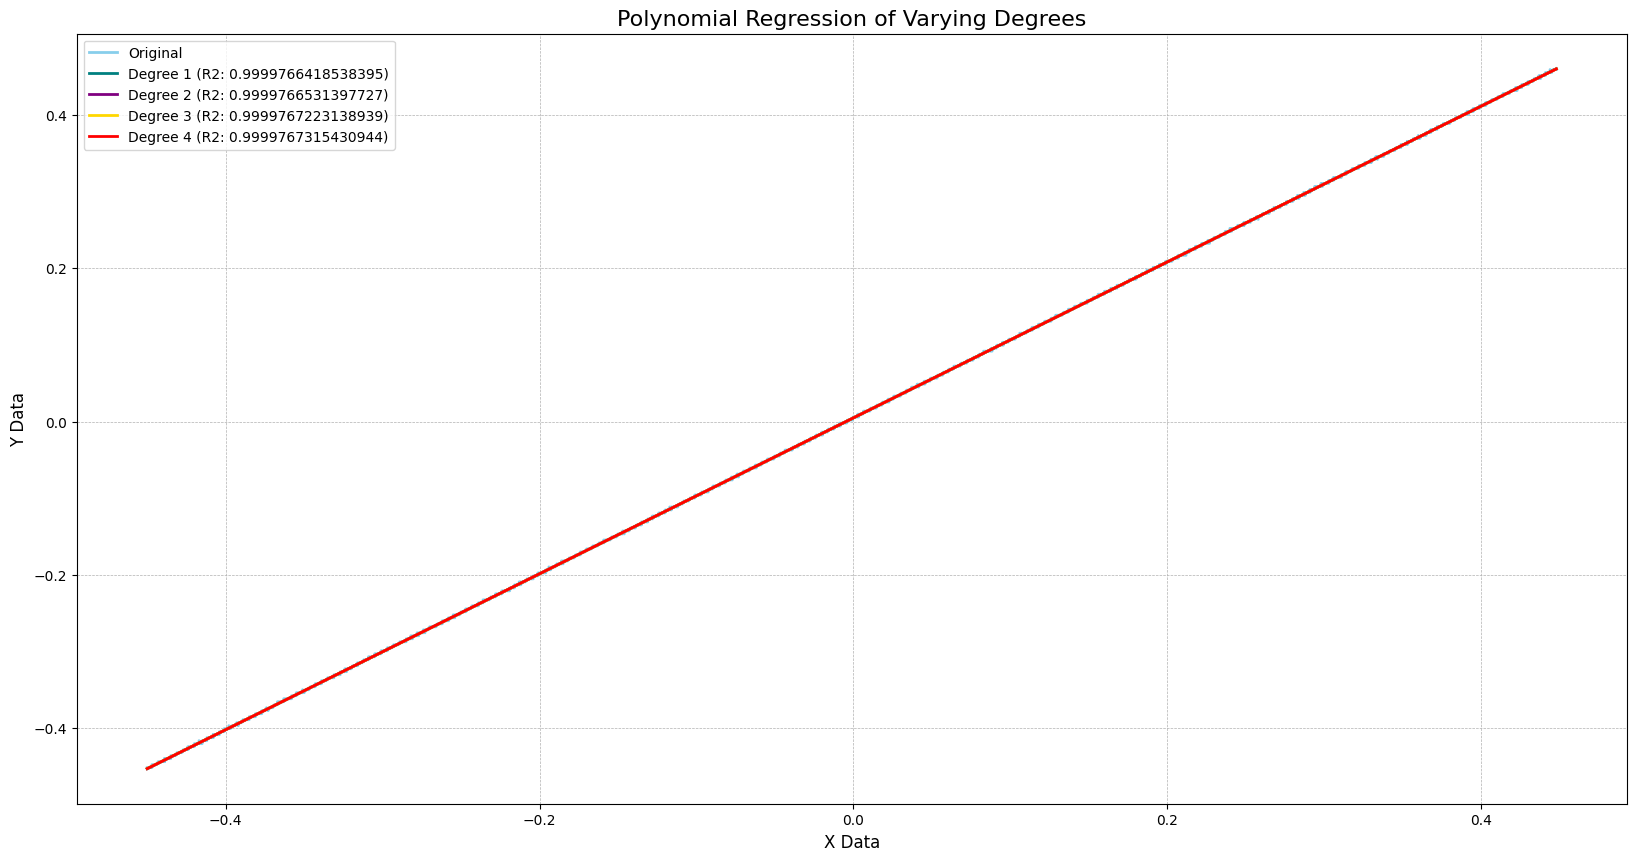

In [5]:
degrees = [1, 2, 3, 4]
plt.figure(figsize=(20, 10))
colors = ['teal', 'purple', 'gold', 'red']

model_list = []
pred_list = []
mse_list = []
r2_list = []
plt.plot(X_data, y_data, color='skyblue', linewidth=2, label='Original')
for idx, degree in enumerate(degrees):
    poly_processor = PolynomialFeatures(degree=degree)
    X_poly = poly_processor.fit_transform(X_data)

    linear_model = LinearRegression()

    linear_model.fit(X_poly, y_data)
    y_pred = linear_model.predict(X_poly)
    mse = mean_squared_error(y_data, y_pred)
    r2 = r2_score(y_data, y_pred)
    print(f"Degree {degree} Model - Mean Squared Error: {mse} - R2 Score: {r2}")

    plt.plot(X_data, y_pred, color=colors[idx], lw=2, label=f'Degree {degree} (R2: {r2})')

    model_list.append(linear_model)
    pred_list.append(y_pred)
    mse_list.append(mse)
    r2_list.append(r2)

plt.title('Polynomial Regression of Varying Degrees', fontsize=16)
plt.xlabel('X Data', fontsize=12)
plt.ylabel('Y Data', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [6]:
degree = degrees[0]
y_pred_best = pred_list[0]
residuals = y_pred_best - y_data

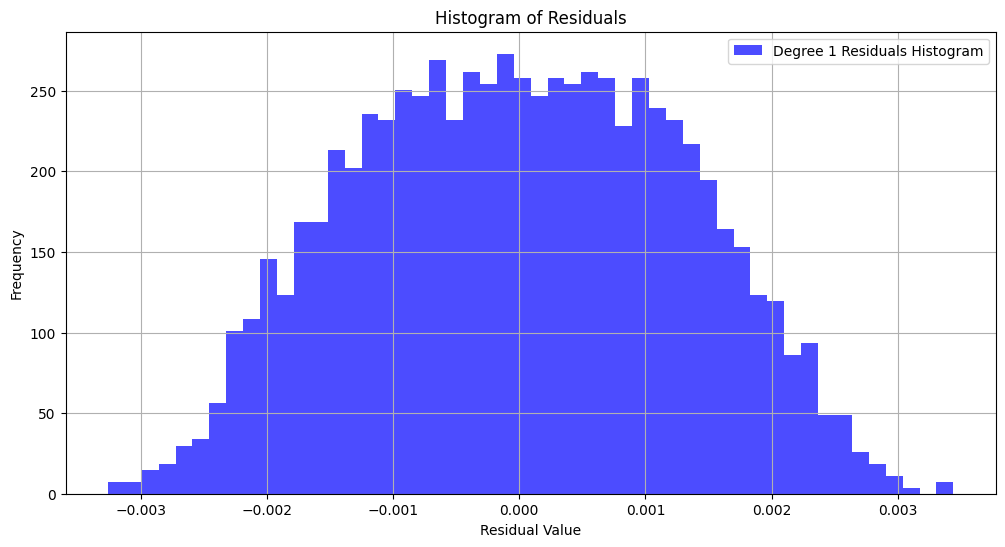

In [7]:
# Histogram of residuals
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=50, density=True, alpha=0.7, color='blue', label=f"Degree {degree} Residuals Histogram")
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

/tmp/ipykernel_20104/4066990343.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


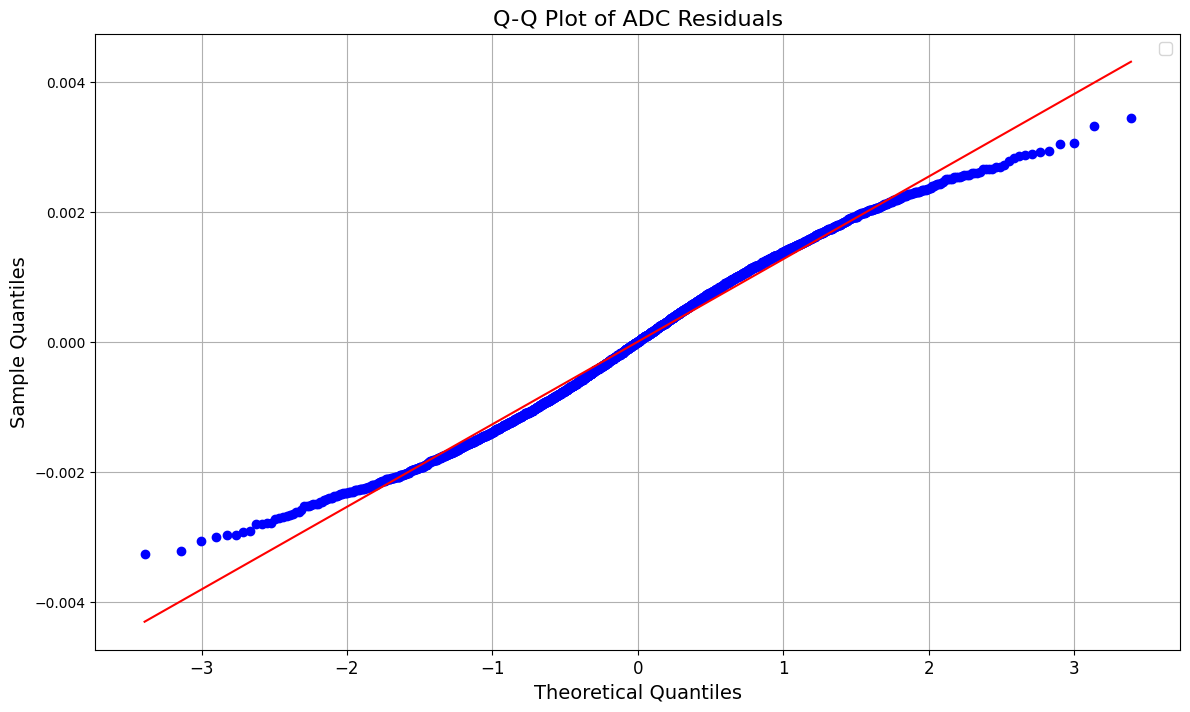

In [8]:
# Q-Q Plot
plt.figure(figsize=(14, 8))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of ADC Residuals', fontsize=16)
plt.xlabel('Theoretical Quantiles', fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.ylabel('Sample Quantiles', fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.savefig("adc_noise_gaussian_qq_plt.png")
plt.show()


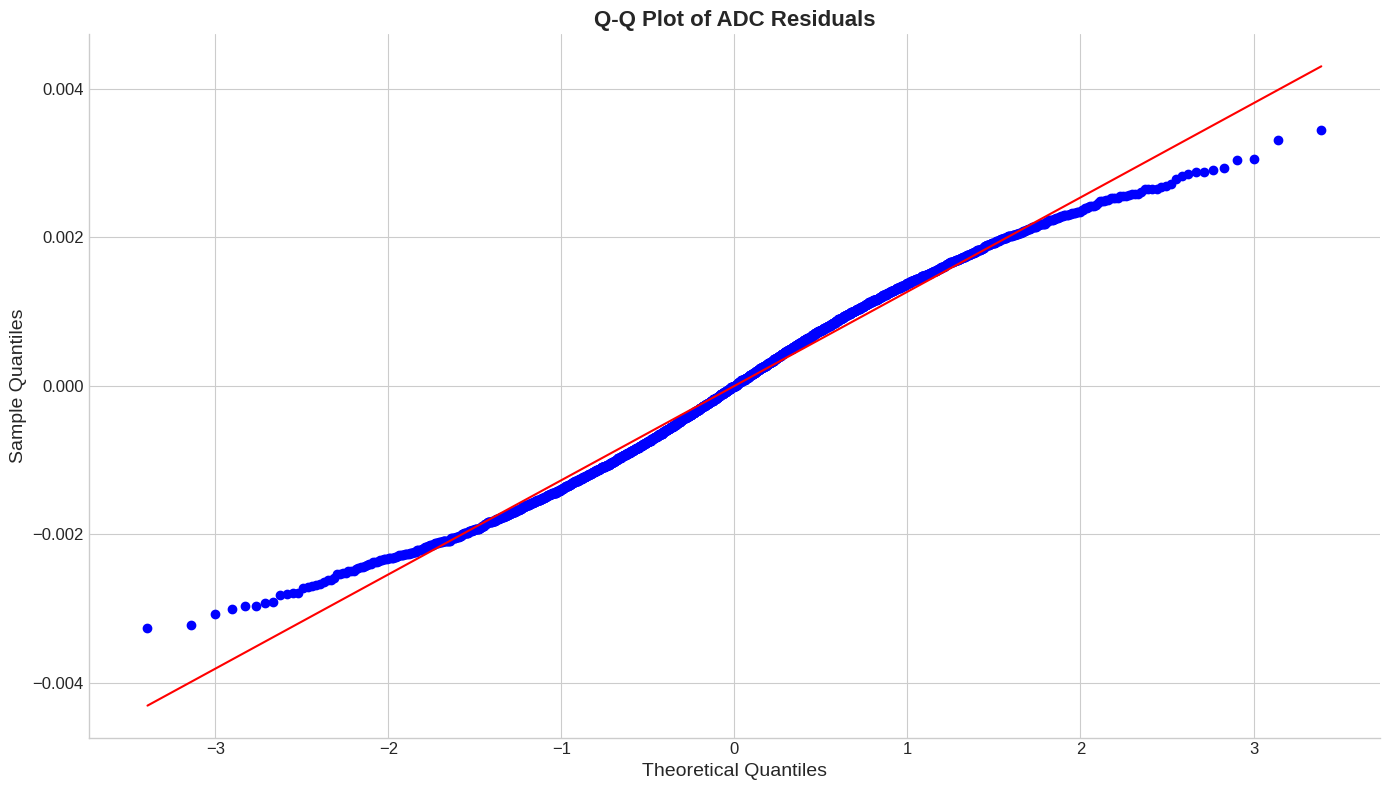

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

# --- 1. Setup and Placeholder Data ---
# Apply the consistent visual style
plt.style.use('seaborn-v0_8-whitegrid')

# --- 2. Plotting ---
# Use subplots for better control over the figure and axes
fig, ax = plt.subplots(figsize=(14, 8))

# Generate the Q-Q plot on the specified axes
stats.probplot(residuals, dist="norm", plot=ax)

# --- 3. Customization for Publication Quality ---
# Set titles and labels with consistent font sizes and styles
ax.set_title('Q-Q Plot of ADC Residuals', fontsize=16, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles', fontsize=14)
ax.set_ylabel('Sample Quantiles', fontsize=14)

# Set tick parameters for both axes
ax.tick_params(axis='both', which='major', labelsize=12)

# Remove top and right spines for a cleaner look
sns.despine()

# Ensure all plot elements fit without overlapping
plt.tight_layout()

# --- 4. Display and Save ---
plt.savefig('adc_noise_gaussian_qq_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('adc_noise_gaussian_qq_plot.svg', format='svg', bbox_inches='tight')
plt.show()

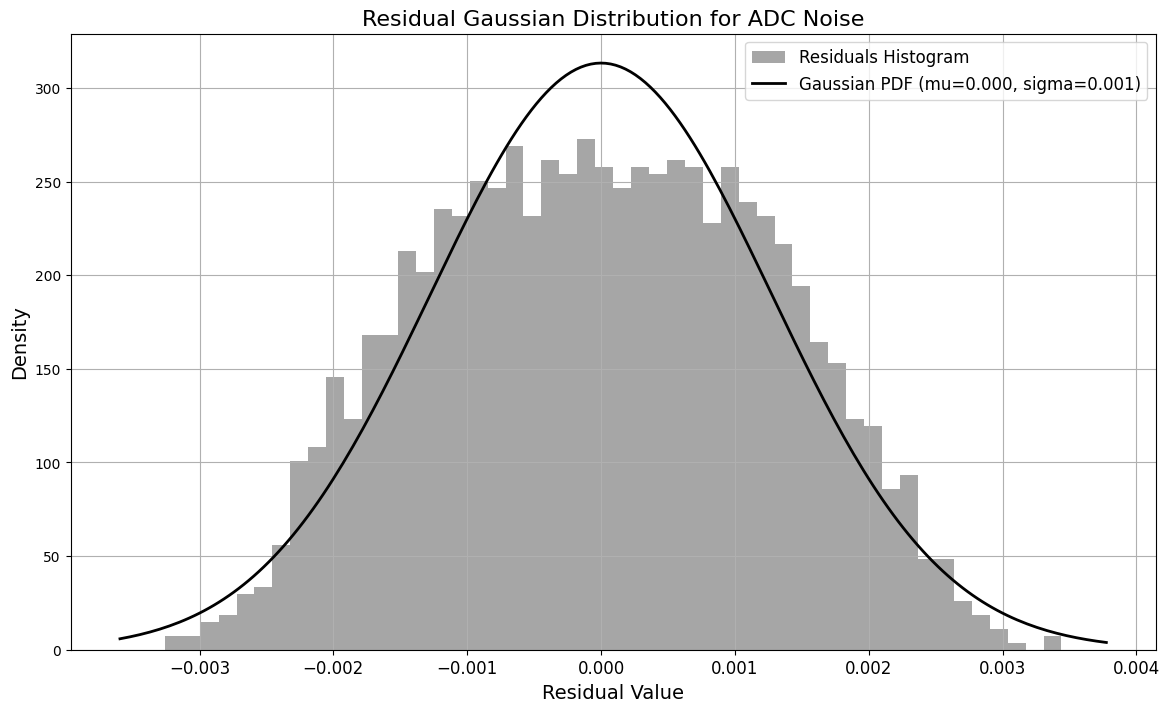

In [12]:
mu, std = stats.norm.fit(residuals)
plt.figure(figsize=(14, 8))
plt.hist(residuals, bins=50, density=True, alpha=0.7, color='gray', label='Residuals Histogram')
xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 200)
pdf_norm = stats.norm.pdf(x_axis, mu, std)
plt.plot(x_axis, pdf_norm, 'k-', linewidth=2, label=f"Gaussian PDF (mu={mu:.3f}, sigma={std:.3f})")
plt.title('Residual Gaussian Distribution for ADC Noise', fontsize=16)
plt.xlabel('Residual Value', fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.ylabel('Density', fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.savefig("adc_noise_gaussian_distribution.png")
plt.show()

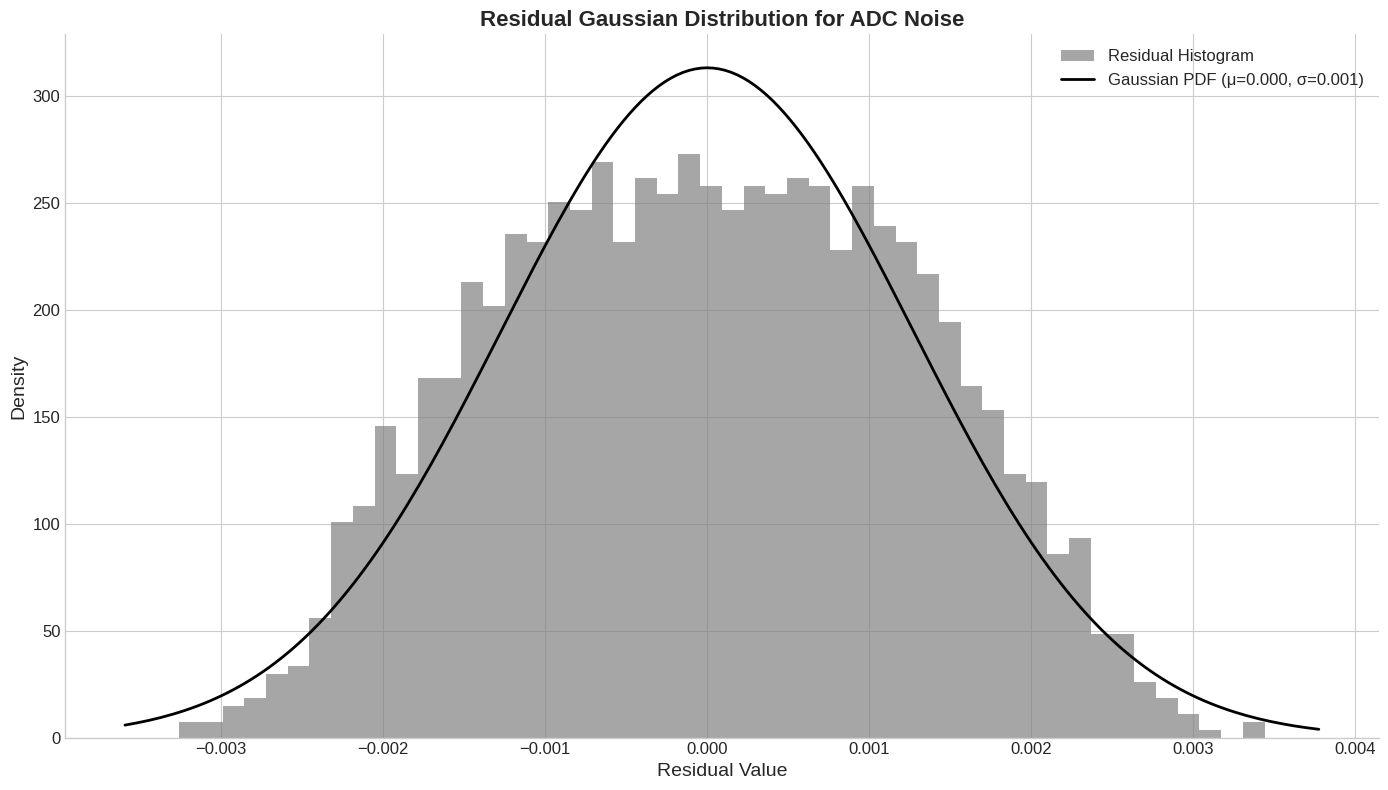

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

# --- 1. Setup and Placeholder Data ---
# Apply the consistent visual style
plt.style.use('seaborn-v0_8-whitegrid')

# --- 2. Plotting ---
# Use subplots for better control over the figure and axes
fig, ax = plt.subplots(figsize=(14, 8))

# Fit a normal distribution to the data
mu, std = stats.norm.fit(residuals)

# Plot the histogram
ax.hist(residuals, bins=50, density=True, alpha=0.7, color='gray', label='Residual Histogram')

# Plot the PDF
xmin, xmax = ax.get_xlim()
x_axis = np.linspace(xmin, xmax, 200)
pdf_norm = stats.norm.pdf(x_axis, mu, std)
ax.plot(x_axis, pdf_norm, 'k-', linewidth=2, label=f"Gaussian PDF (μ={mu:.3f}, σ={std:.3f})")

# --- 3. Customization for Publication Quality ---
# Set titles and labels with consistent font sizes and styles
ax.set_title('Residual Gaussian Distribution for ADC Noise', fontsize=16, fontweight='bold')
ax.set_xlabel('Residual Value', fontsize=14)
ax.set_ylabel('Density', fontsize=14)

# Set tick parameters for both axes
ax.tick_params(axis='both', which='major', labelsize=12)

# Set legend font size
ax.legend(fontsize=12)

# Remove top and right spines for a cleaner look
sns.despine()

# Ensure all plot elements fit without overlapping
plt.tight_layout()

# --- 4. Display and Save ---
plt.savefig('adc_noise_gaussian_dist.pdf', dpi=300, bbox_inches='tight')
plt.savefig('adc_noise_gaussian_dist.svg', format='svg', bbox_inches='tight')
plt.show()